IMT 2200 - Introducción a Ciencia de Datos<br>
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

---

## Tarea 01 – Cargando y Analizando Datos

- **Fecha de Entrega:** martes 26 de agosto de 2025, a las 23:59.
- 
**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en l emódulo de Tara 01 habilitado en Canvas.




## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tara.

- Deben hacer sus consultas y comentarios sobre la Tarea a traves del canal de Tareas en eo del curso en Canvas.os.
cteriza.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

Para esta tarea, tendremos como objetivo comprender cómo han cambiado los juegos de mesa en los últimos 40 años. Específicamente queremos saber qué tipos de juegos se han vuelto más comunes hoy en día y qué los caracteriza.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

## 2. Datos

Estaremos utilizando información extraída desde [BoardGameGeek.com](https://boardgamegeek.com/), una plataforma para aficionados de los juegos de mesa, que permite a sus usuarios registrar, calificar e intercambiar sus juegos favoritos. Actualmente, BGG es una de las bases de datos más extensa y diversa de juegos de mesa.

El dataset con el que trabajaremos consiste en un grupo de archivos CSV que contienen información sobre más de 100.000 juegos de mesa almacenados en la plataforma. Este puede descargarse directamente desde el siguiente enlace: https://www.kaggle.com/datasets/mshepherd/board-games Para descargar los datos, haga click en el botón de **Download**, donde podrá descargar los archivos como `.zip`, o bien utilizar la API de Kaggle.

Para el desarrollo de esta tarea, solo utilizaremos los archivos con el prefijo `bgg_`.

**Si utiliza la API de Kaggle para descargar los datos, deje el código utilizado en la siguiente celda:**

In [28]:
# Descarga de datos desde Kaggle

### 2.1 Librerías

Para esta tarea recomendamos al menos usar las librerías indicadas en la siguiente celda del Notebook. Puede agregar otras si lo estima conveniente para responder de mejor forma las preguntas de la Tarea.

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 3. Desarrollo

Para cada una de las siguientes preguntas o actividades incluya una o más celdas de código y Markdown con las respuestas o comentarios necesarios para contestar la pregunta o lograr la actividad. Agregue sus celdas a continuación de cada pregunta para que el Notebook quede ordenado.

En el caso de gráficos, figuras o tablas, asegúrese que todas tengan título, etiquetas en los ejes o haya claridad de los contenidos.

### 3.1 DataFrame unificado (1 punto)

Vamos a cargar en un DataFrame los datos de juegos guardados en el documento `bgg_GameItem.csv`. Al inspeccionar nuestros datos, podemos notar que los valores de ciertas comunas vienen "codificados" con ID. Para comenzar, vamos a juntar la información de los distintos archivos descargados.

**a) (0.8 pts)** Genere un DataFrame único con toda la información de cada juego, incluyendo: nombres de artistas y diseñadores involucrados, mecánicas, categorías, tipo, familia y editorial. Guarde este DataFrame en un nuevo archivo CSV.

In [30]:
# Leemos los csv
df = pd.read_csv('bgg_GameItem.csv')
category = pd.read_csv('bgg_Category.csv')
gamefamily = pd.read_csv('bgg_GameFamily.csv')
gametype = pd.read_csv('bgg_GameType.csv')
mechanic = pd.read_csv('bgg_Mechanic.csv')
person = pd.read_csv('bgg_Person.csv')
publisher = pd.read_csv('bgg_Publisher.csv')
# Hacemos una funcion que retorna el nombre que se tiene segun su ID
def cambiar_id(texto, dic):
    # con str() se garantiza que sea string, porque o si no da error.
    lista = str(texto).split(",")
    texto_cambiado = ""
    for x in lista:
        if x.isdigit():
            nombre = dic[int(x)]
        else:
            nombre = x
        if x == lista[-1]:
            texto_cambiado += nombre
        else:
            texto_cambiado += nombre + ","
    return texto_cambiado
# Se crea otra funcion para actualizar los IDs por los nombres
def cambiar_a_nombre(name_col, dic):
    lista = []
    for x in df[name_col]:
        lista.append(cambiar_id(x, dic))
    df[name_col] = lista
# Ahora transformamos a diccionario {id: name} cada csv que tenga el ID con el respectivo nombre
""""
Para crear estos diccionarios me apoye de:
* https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.set_index.html
* https://es.stackoverflow.com/questions/293320/generar-un-diccionario-a-partir-de-un-dataframe-pandas

"""
cat_diccionario = category.set_index('bgg_id')['name'].to_dict()
fam_diccionario = gamefamily.set_index('bgg_id')['name'].to_dict()
type_diccionario = gametype.set_index('bgg_id')['name'].to_dict()
mech_diccionario = mechanic.set_index('bgg_id')['name'].to_dict()
pers_diccionario = person.set_index('bgg_id')['name'].to_dict()
publ_diccionario = publisher.set_index('bgg_id')['name'].to_dict()
# Ahora se cambian los IDs por los nombres respectivos
cambiar_a_nombre("category", cat_diccionario)
cambiar_a_nombre("family", fam_diccionario)
cambiar_a_nombre("game_type", type_diccionario)
cambiar_a_nombre("mechanic", mech_diccionario)
cambiar_a_nombre("designer", pers_diccionario)
cambiar_a_nombre("artist", pers_diccionario)
cambiar_a_nombre("publisher", publ_diccionario)
df.to_csv("bgg_fulldata.csv")

**b) (0.2 pts)** ¿Cuánto espacio en disco ocupa este DataFrame? ¿Cuánto espacio en disco ocupan los documentos CSV separados? ¿A qué se debe esta diferencia? Comente.



El DataFrame creado ocupa 31,080 KB, mientras que los otros documentos CSV que contienen los datos divididos por ids ocupan un 17,593 KB aproximadamente. Esta diferencia, se puede deber a que en el DataFrame creado se ocupan los nombres completos de los datos en lugar de un ID que los conecte (como en los documentos que estan divididos). Esto provoca que se repitan los mismos nombres muchas veces, lo que incrementaria el numero de bytes. 

Por otro lado, si los datos se dividieran y se representaran mediantes los IDs, el nombre del dato solo se repetiria una vez (en el archivo correspondiente), y el ID (que generalmente ocupa menos bytes que el nombre completo del dato) se repetiria dentro de todos los documentos que requieran este dato, lo que haria que los documentos que estan divididos sean mas livianos y eficientes que un solo documento donde todos los nombres de los datos se repiten. 

### 3.2 Juegos publicados anualmente (1.5 puntos)


**a) (0.5 pts)** Limpie los datos para dejar solo aquellos que tienen valores válidos de año de publicación. Luego responda: ¿cuál es el rango de años con el que estamos trabajando? ¿Tienen sentido estos años?


In [31]:
minimo_1 = df['year'].min()
maximo_1 = df['year'].max()
print(f"El rango antes de limpiar los datos esta entre {minimo_1} y {maximo_1}.")
# Filtra el df para que solo se queden las filas donde "year" sea un numero y no NaN
"""
Me guie con la documentacion de Panda:
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.notna.html#pandas.DataFrame.notna
"""
df_limpio = df[df['year'].notna()]
df_limpio = df_limpio[df_limpio['year'] <= 2025]
minimo_2 = df_limpio['year'].min()
maximo_2 = df_limpio['year'].max()
print(f"El rango despues de limpiar los datos esta entre {minimo_2} y {maximo_2}.")

El rango antes de limpiar los datos esta entre -3500.0 y 2026.0.
El rango despues de limpiar los datos esta entre -3500.0 y 2025.0.


El rango de los años antes de limpiar los datos esta entre -3500 y 2026, este rango esta mal, ya que hay años en los que indica 2026, cuando todavia estamos en 2025 (en el momento que se hace este jupyter). 

Despues de limpiar los datos, el rango esta entre -3500 y 2025, este rango esta bien, ya que aunque el minimo este en el año -3500, este se interpretan como años a.C, mientras que el maximo esta en 2025 que es correcto ya que estamos en ese año

**b) (0.5 pts)** Seleccione solamente los juegos entre los años 1980 y 2025. Luego grafique la cantidad de juegos publicados por año. ¿Cómo es esta tendencia? Comente.

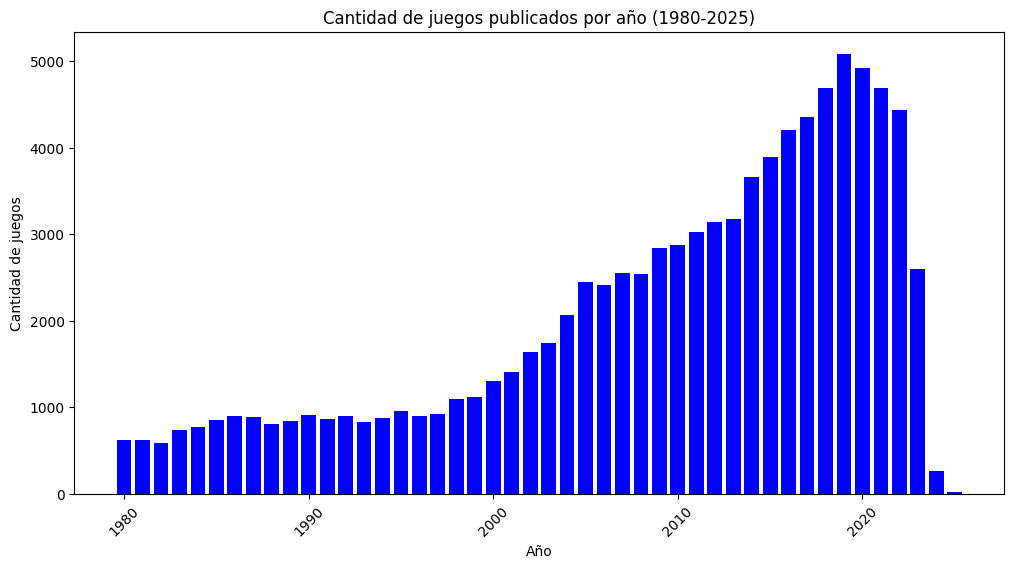

In [32]:
df_filtrado = df_limpio[df_limpio['year'] >= 1980]
df_filtrado = df_filtrado[df_filtrado['year'] <= 2025]
df_filtrado_anio = df_filtrado['year'].value_counts()
plt.figure(figsize=(12,6))
plt.title("Cantidad de juegos publicados por año (1980-2025)")
plt.bar(df_filtrado_anio.index, df_filtrado_anio.values, color='blue')
plt.xlabel("Año")
plt.ylabel("Cantidad de juegos")
plt.xticks(rotation=45)
plt.show()


La tendencia sobre la cantidad de juegos publicados por años es que entre 1980 y 1997 se mantiene muy similar (estable), solo bajando y subiendo un poco, no obstante entre 1998 y 2020 se muestra un aumento muy grande en la publicacion de juegos anuales. Sin embargo, entre 2020 y 2025 se muestra una disminucion exponencial en la publicacion de juegos anuales.

Como se puede observar en el año 2020 se cuadriplico (aproximadamente) la cantidad de juegos publicados con respecto a 1980. Tambien como se observa, en 2024 la cantidad de publicacion por año disminuyo a menos de 500 publicaciones anuales, pero en 2025 la cantidad de publicaciones anuales esta por bajo de 100 aproximadamente.

**c) (0.5 pts)** ¿Entre qué años hubo un mayor aumento de publicación de juegos de mesa según los registros de BGG?

In [33]:
"""
Aqui me ayudo ChatGPT:
le mande: que puedo ocupar de pandas para ver entre que años hubo un mayor aumento de un dato?

Respondio: 
¡Buena pregunta! Si tienes una serie temporal con datos anuales y quieres identificar entre qué años hubo un mayor aumento de un dato usando pandas, puedes hacer lo siguiente:

Pasos básicos:

Ordenar los datos por año (si no están ordenados).

Calcular la diferencia año a año usando .diff().

Encontrar la diferencia máxima.

Identificar los años correspondientes a ese aumento.

Que usar:

.diff() calcula la diferencia entre un valor y el anterior.

.idxmax() encuentra el índice donde esa diferencia es máxima.

Usamos ese índice para obtener los años entre los cuales ocurrió ese mayor salto.

tambien me apoye de:
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_index.html#pandas.DataFrame.sort_index

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.diff.html#pandas.DataFrame.diff

https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.idxmax.html#pandas.DataFrame.idxmax
"""

conteo = df_filtrado_anio.sort_index()
diferencia = conteo.diff()
anio_mayor_aumento = diferencia.idxmax()
cant_aumento = diferencia.max()
print(f"El mayor aumento ocurrio entre {anio_mayor_aumento - 1} y {anio_mayor_aumento}, con un incremento de {cant_aumento} juegos publicados anuales")

El mayor aumento ocurrio entre 2013.0 y 2014.0, con un incremento de 484.0 juegos publicados anuales


### 3.3 Análisis de duración y complejidad (1.5 puntos)

Si bien hay muchas posibles características que podemos explorar para los juegos de mesa, esta vez nos centraremos en el tiempo de juego y la complejidad. En esta sección queremos comprender si se ha modificado notablemente la duración promedio y la percepción de complejidad de los juegos de mesa a través de los años.

**a) (0.3 pts)** Inspecciones y filtre los datos que tengan valores válidos para: tiempo mínimo de juego, tiempo máximo de juego y complejidad. En el caso de que existan "outliers", puede descartarlos, cosiderando un rango razonable para las variables anteriores. Justifique su desición.

In [34]:
"""
Para calcular los outliers me ayude de:
https://medium.com/@martacasdelg/c%C3%B3mo-identificar-y-tratar-outliers-con-python-bf7dd530fc3
"""
print(f"Antes del filtro: {len(df_limpio)}")
df_limpio = df_limpio[df_limpio['min_time'] >= 0]
df_limpio = df_limpio[df_limpio['max_time'] >= 0]
# No se cuenta el 0 porque me indefine promedio_ajustado
df_limpio = df_limpio[df_limpio['complexity'] > 0]
promedio = (df_limpio['min_time'] + df_limpio['max_time']) / 2
# Aca se ajusta el tiempo segun la dificultad
promedio_ajustado = promedio/ df_limpio['complexity']
q_1 = promedio_ajustado.quantile(0.25)
q_3 = promedio_ajustado.quantile(0.75)
iqr = q_3 - q_1
df_limpio = df_limpio[(promedio_ajustado >= (q_1 - 1.5 * iqr))]
df_limpio = df_limpio[promedio_ajustado <= (q_3 + 1.5 * iqr)]   
print(f"Despues del filtro: {len(df_limpio)}")

Antes del filtro: 104217
Despues del filtro: 38878


Se descarton los outliers usando el rango intercuartilico (IQR), ya que nos permite ver valores que esten muy lejos del centro de datos (Q2). Ademas, agregue que se dividiera el promedio de tiempos dependiendo de la dificultad que tuviera el juego para comparar de manera un poco mas justa.

**b) (0.2 pts)** Veremos ahora si ha cambiado la duración promedio de los juegos de mesa en nuestro rango de años seleccionado. Primero, cree una nueva columna `avg_time` en el dataset con la duración promedio supuesta para cada juego.

In [35]:
# No me quedo claro si tenia que colocar mi promedio ajustado de tiempo,
# asi que hice el promedio simple
df_limpio['avg_time'] = (df_limpio['min_time'] + df_limpio['max_time']) / 2

**c) (0.5 pts)** Grafique la duración promedio de juegos al año entre 1980 y 2025. ¿Existe alguna tendencia? Asegúrese de colocar las unidades correspondientes en sus ejes si es necesario. Comente sus resultados.

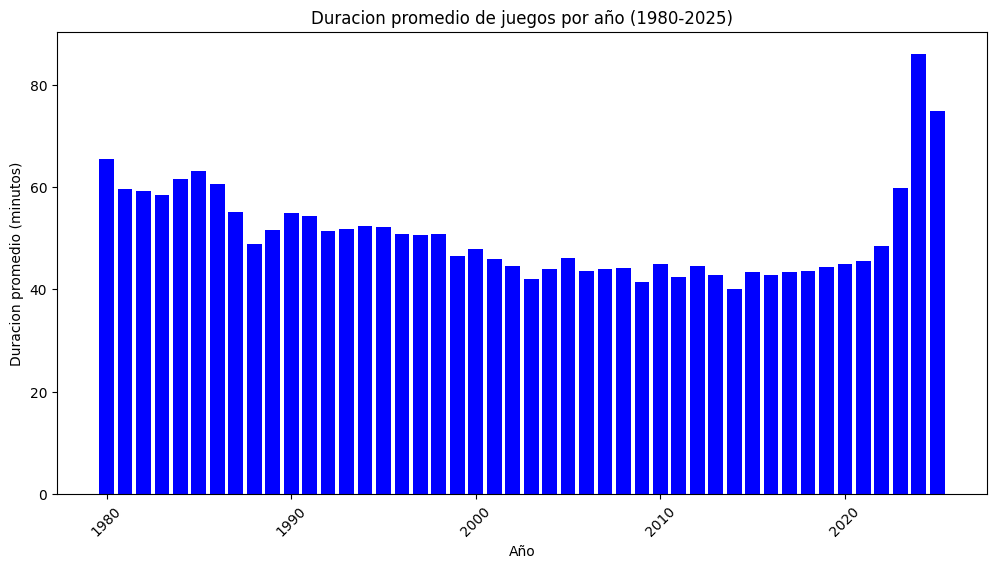

In [37]:
"""
Me ayudo ChatGPT en sacar el promedio por años:
Le dije: como puedo sacar el promedio de algo por un dato en un dataframe

Me respondio: ¡Claro! Para sacar el promedio de algo por un dato en un DataFrame de pandas (asumo que usas Python), normalmente usas el método groupby() y luego aplicas mean().

"""

df_filtrado_2 = df_limpio[df_limpio['year'] >= 1980]
df_filtrado_2 = df_filtrado_2[df_filtrado_2['year'] <= 2025]
df_promedio_anio = df_filtrado_2.groupby('year')
df_promedio_anio = df_promedio_anio['avg_time'].mean()
plt.figure(figsize=(12,6))
plt.title("Duracion promedio de juegos por año (1980-2025)")
plt.bar(df_promedio_anio.index, df_promedio_anio.values, color='blue')
plt.xlabel("Año")
plt.ylabel("Duracion promedio (minutos)")
plt.xticks(rotation=45)
plt.show()

La duracion promedio se mantiene medianamente estable durante 1980 y 1990, despues entre 1990 y 2020 se ve una disminucion leve en los promedios pero nada significativo, no obstante entre 2023 y 2025 se disparo la duracion promedio.

**d) (0.5 pts)** Nos interesa saber si los juegos de mesa recientes son más complejos que aquellos publicados antes de los 2000. BoardGameGeek permite evaluar la complejidad (o "weight") de un juego en una escala de 1 a 5, siendo 1 un juego "liviano" o fácil de entender, y 5 un juego "pesado" o complejo. Primero, seleccione los juegos que han sido evaluados por al menos 100 usuarios. Luego grafique la complejidad promedio de los juegos según año. Responda: ¿ha cambiado la percepción de complejidad entre juegos entre 1980 y la actualidad?

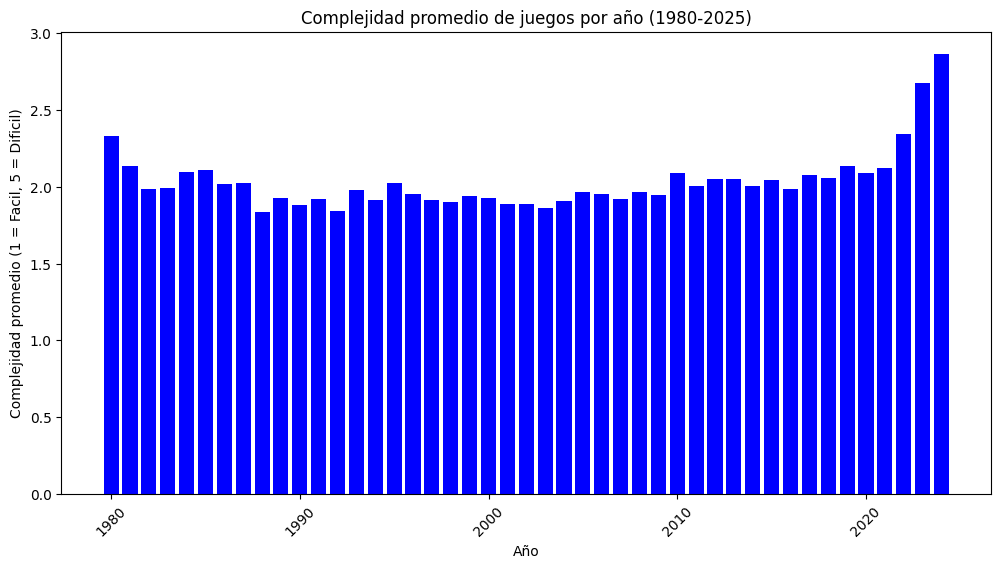

In [39]:
df_fil = df_limpio[df_limpio['num_votes'] >= 100]
df_fil = df_fil[df_fil['year'] >= 1980]
df_fil = df_fil[df_fil['year'] <= 2025]
# Se asegura que complejidad este dentro del rango estipulado
df_fil = df_fil[df_fil['complexity'] >= 1]
df_fil = df_fil[df_fil['complexity'] <= 5]
complejidad_anual = df_fil.groupby('year')
complejidad_anual = complejidad_anual['complexity'].mean()
plt.figure(figsize=(12,6))
plt.title("Complejidad promedio de juegos por año (1980-2025)")
plt.bar(complejidad_anual.index, complejidad_anual.values, color='blue')
plt.xlabel("Año")
plt.ylabel("Complejidad promedio (1 = Facil, 5 = Dificil)")
plt.xticks(rotation=45)
plt.show()


En los ultimos años (2021-2024) la percepcion de complejidad ha subido pero tampoco es un salto exagerado, con respecto a los demas años se ha mantenido casi estable, indicando que no ha subido ni bajado la percepcion de complejidad de los juegos, lo que puede decir que al paso de los años la dificultad se ha mantenido con el paso de los años. 

### 3.4 Análisis de categorías comunes (2 puntos)

Existe una gran diversidad de categorías de juegos de mesa. Ahora nos concentraremos en un grupo específico de ellas, con el fin de analizar cómo a cambiado la cantidad de juegos de estas clases desde 1980 hasta hoy.

**a) (0.7 pts)** ¿Cuáles son las 5 categorías más comunes en los juegos del dataset? Muestre la cantidad de juegos que hay de cada una. Puede graficar estos valores, o bien, entregar un DataFrame con sus valores.

In [46]:
categorias_filtradas = df_limpio[df_limpio['category'].notna()]
categorias = categorias_filtradas['category']
# Se crea una lista con todas las categorias
todas_categorias = []
# Se separan las categorias que tienen coma
for cat in categorias:
    separado = []
    for c in cat.split(","):
        separado.append(c)
    todas_categorias.extend(separado)
# Creo un diccionario donde se cuenta la cantidad de veces que se repite una categoria
conteo = {}
for categ in todas_categorias:
    if categ in conteo:
        conteo[categ] += 1
    else:
        conteo[categ] = 1
cat_cant = list(conteo.items())

def obtener_cantidad(lista):
    return lista[1]
cat_ordenadas = sorted(cat_cant, key=obtener_cantidad, reverse=True)
top5 = cat_ordenadas[:5]
top5_df = pd.DataFrame(top5, columns=["category", "cantidad"])
top5_df.head()

,category,cantidad
0,Card Game,11742
1,Wargame,5139
2,Children's Game,4390
3,Fantasy,4300
4,Dice,3779


**b) (0.3 pts)** Para cada una de estas 5 categorías, cree un DataFrame que contenga la cantidad de juegos en el dataset según año. Luego junte estos DataFrames en uno solo con los atributos de "Año", "Categoría" y "Cantidad".

**c) (1 pto)** Grafique, en un solo gráfico y con distintos colores, la cantidad de juegos por año según categoría. Preocúpese de ponerle etiquetas al gráfico para identificar cada categoría y una leyenda donde se muestre cada una. Comente: ¿ha habido un cambio entre los juegos más comunes en los años 80 y hoy?


### 3.5 Análisis Crítico (Bono +0.5 puntos)

¿Qué limitaciones o problemas encontraste en los datos?